# Assignment 3
### Due 9/21. Do four of five.

### Grace George

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Question 1

1. 
- Open the NHANES (or Ames prices or college completion datasets, if you prefer)
- Find two categorical variables of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis like we did with police use of force, but always be aware of how dirty the data are)
- Compute a contingency table for your categorical $X$ and $Y$
- Discuss any interesting patterns (or lack of one) that you observe

In [2]:
meta=pd.read_csv('/Users/graceegeorge/DS5030_public_repo/data/nhanes_meta_17_18.csv')


In [3]:
nhanes=pd.read_csv('/Users/graceegeorge/DS5030_public_repo/data/nhanes_data_17_18.csv',low_memory=False)

In [4]:
nhanes["Gender"].isna().value_counts()


Gender
False    8366
Name: count, dtype: int64

In [5]:
nhanes["MaritalStatus"].isna().value_counts()

MaritalStatus
False    5260
True     3106
Name: count, dtype: int64

In [6]:
gdf=nhanes.loc[:,["Gender","MaritalStatus"]]
gdf.value_counts()

Gender  MaritalStatus      
Male    Married                1371
Female  Married                1245
Male    Never married           486
Female  Never married           462
        Divorced                330
        Widowed                 324
Male    Divorced                267
Female  Living with partner     240
Male    Living with partner     238
Female  Separated               120
Male    Widowed                 103
        Separated                74
Name: count, dtype: int64

In [7]:
pd.crosstab(nhanes['Gender'],nhanes['MaritalStatus'])

MaritalStatus,Divorced,Living with partner,Married,Never married,Separated,Widowed
Gender,,,,,,
Female,330,240,1245,462,120,324
Male,267,238,1371,486,74,103


There are more female in the sample, so it would be more helpful to look at proportions, but I did noticed some patterns when looking ath the data. One pattern I notice is that women tend to be widowed or seperated more. I wonder if the widow rates has to do with women living longer than men.

### Question 2

2. 
- Open the NHANES dataset
- Find a categorical and numeric variable of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis, but always be aware of them)
- Make descriptive tables and grouped kernel density plots to represent the variation in your numeric $Y$ conditional on your categorical $X$
- Discuss any interesting patterns (or lack of one) that you observe

In [8]:
nhanes['general_health_na']=nhanes['GeneralHealthCondition'].isna()
nhanes['general_health_na'].value_counts()

general_health_na
False    5964
True     2402
Name: count, dtype: int64

In [9]:
nhanes['Avg_Cig_na']=nhanes['AvgCigarettesdayDuringPast30Days'].isna()
nhanes['Avg_Cig_na'].value_counts()

Avg_Cig_na
True     7392
False     974
Name: count, dtype: int64

In [10]:
nhanes['log_avg_cig']=np.log(nhanes['AvgCigarettesdayDuringPast30Days'])

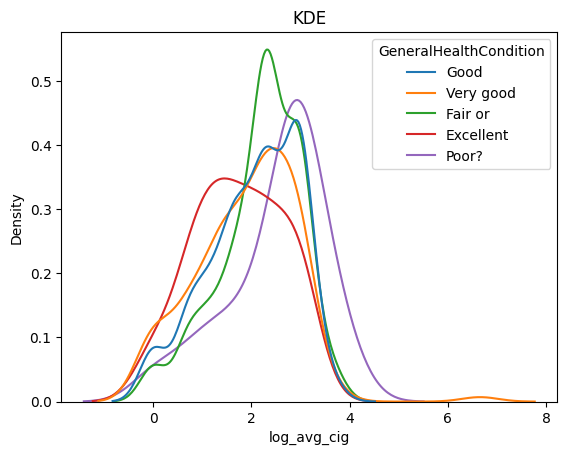

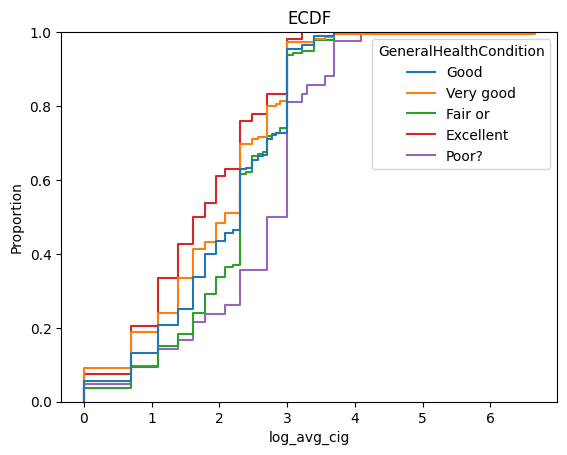

In [11]:
conditioner = 'GeneralHealthCondition'
sns.kdeplot( data=nhanes, x='log_avg_cig', hue=conditioner, common_norm=False ).set(title='KDE')
plt.show()
sns.ecdfplot( data=nhanes, x='log_avg_cig', hue=conditioner).set(title='ECDF')
plt.show()


I transformed the average cigarettes smoked in the last 30 days to be able to read the data more easily. I noticed that people who have a poor health condition have a higher proportion of people that smoke more cigarretes. With the other general health conditions, there was not a huge difference in the average cigerattes smoked in last 30 days.

### Question 3

3. 
We showed that the mean and median could be discovered by minimizing various kinds of loss functions; this is what machine learning is. To make a prediction $\hat{y}(z)$ of $Y$ when $X=z$, minimize the mean squared error:
$$
MSE(\hat{y}(z)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(z) \right\rbrace^2 \frac{1}{h}k\left(\frac{z-x_i}{h}\right)
$$
Show that the solution to this problem is the LCLS/Naradaya-Watson estimator.

### Question 4

4. 
- Write a class or set of functions that implement the LCLS/Naradaya-Watson estimator, using the Silverman plug-in estimate for the conditioning variable $X$ as the bandwidth.
- From one of the course data sets, find two numeric variables of interest, analyze their relationship with the the LCLS/Naradaya-Watson estimator, and discuss your results.

In [4]:
nhanes['WaistCircumferenceCm']
nhanes['WeightKg']

0        13.7
1        13.9
2        79.5
3        66.3
4        45.4
        ...  
8361     49.0
8362     97.4
8363     69.1
8364    111.9
8365    111.5
Name: WeightKg, Length: 8366, dtype: float64

In [5]:
gdf=nhanes.loc[:,['WaistCircumferenceCm','WeightKg']]
gdf = gdf.dropna()
gdf = gdf.reset_index()

x = gdf['WaistCircumferenceCm']
y= gdf['WeightKg']
# grid=np.sort(np.unique(x))
# grid
# grid=np.sort(np.unique(x))
# z=grid[2]
# num=0
# dem=0
# k=1/np.sqrt(2*np.pi)
# h=1.06 * np.std(x)* len(x) **(-0.2)

# def k(u):
#     return np.exp(-u**2)/np.sqrt(2*np.pi)


# for z in grid:
#     for i in range(len(x)):
#         u = (x[i] -z)/h
#         num+=y[i] * k(u)
#         dem+=k(u)
#     y_hat=num/dem
    
# print(y_hat)
    

In [6]:

def k(u):
    return np.exp(-u**2)/np.sqrt(2*np.pi)

def lcls(x,y,h=None,plot=True):
    grid=np.sort(np.unique(x))
       #k=1/np.sqrt(2*np.pi)
    if h is None:
        h=1.06 * np.std(x)* len(x) **(-0.2)

    y_hat = []    
    for z in grid:
        num=0
        dem=0
        for i in range(len(x)):
            u = (x[i] -z)/h
            num+=y[i] * k(u)
            dem+=k(u)
        y_hat_z=num/dem
        y_hat.append(y_hat_z)
        
    if plot:
        sns.scatterplot(data=gdf, y='WeightKg', x='WaistCircumferenceCm',alpha=.05)
        sns.lineplot(x=grid,y=y_hat, color='orange')
        plt.show()

    # return y_hat, grid # Comment out return so output does not print out full list of y hats
    
    

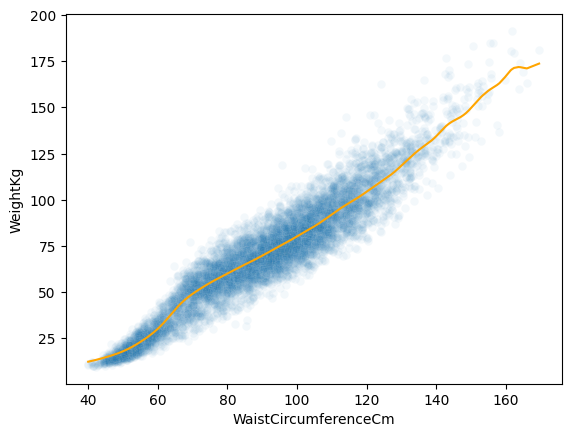

In [7]:
lcls(x,y)

### Question 5

5. 
- In any of the available data sets, investigate the relationships between pairs of variables $(X,Y)$ with a scatterplot and CEF (for example, price on area)
- Is this relationship plausibly causal, or are there missing variables that might explain at least part of the relationship between your variables? These can be "conceptual" rather than "practical"; for example, 'talent' or 'grit' probably explain education outcomes, but are almost impossible to measure. We are asking whether there are hypothetical **threats to causal identification** of the effect of $X$ on $Y$.
- Explain how, regardless of the threat to causal identification, you can still use your model to predict $Y$ given $X$, as long as you don't intervene in the system to control the outcome

In [1]:
housing=pd.read_csv('/Users/graceegeorge/DS5030_public_repo/data/ames_prices.csv')

NameError: name 'pd' is not defined

In [ ]:
housing['Full.Bath'].value_counts()
housing['Full.Bath'].isna().value_counts()

Full.Bath
False    2930
Name: count, dtype: int64

,price
Full.Bath,
0,171177.750000
1,134646.147193
2,214510.599869
3,322140.031250
4,241875.000000


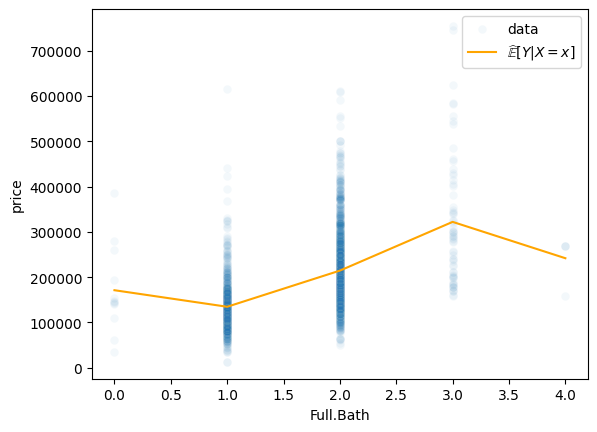

In [ ]:
means = housing.loc[:,['price','Full.Bath']].groupby('Full.Bath').mean()
sns.scatterplot(data=housing, y='price', x='Full.Bath',alpha=.05, label='data')
sns.lineplot(data=means, x='Full.Bath',y='price',color='orange', label='$\\widehat{\\mathbb{E}}[Y|X=x]$')

means

I wanted to see if the number of full bathrooms in the house affects the price. There were no missing values in the full bath column so our data shows the full picture. We cannot conclude this is a causal relationship between the number of full bathrooms and the price of the house because we know there are other factors such as size and number of bedrooms that affect the house. We can still make predictions about housing price based on the number of full bathrooms though.It seems like from 1 to 3 bathrooms, the price increases as the number of full bathroom increases. It seems like houses with four full bathrooms cost less that houses with three, but there is much less observation of housings with four full bath than three, so if we had a bigger dataset we might be able to make more conclusions. However,  based on what we see between 1 and 3 bathrooms, it seems that a house might be more expensive the more full bathrooms it has. 